In [26]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from matplotlib import pyplot as plt

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [ ]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c state-farm-distracted-driver-detection

100% 4.00G/4.00G [00:33<00:00, 129MB/s]



In [ ]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [25]:
df = pd.read_csv("/content/data/driver_imgs_list.csv")
df.head()

,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [ ]:
drivers = df['subject'].unique()
print("Total drivers:", len(drivers))

Total drivers: 26


In [ ]:
train_drivers, temp_drivers = train_test_split(
    drivers,
    test_size=0.4,
    random_state=42
)

val_drivers, test_drivers = train_test_split(
    temp_drivers,
    test_size=0.5,
    random_state=42
)

print("Train drivers:", len(train_drivers))
print("Val drivers:", len(val_drivers))
print("Test drivers:", len(test_drivers))

Train drivers: 15
Val drivers: 5
Test drivers: 6


In [ ]:
train_df = df[df['subject'].isin(train_drivers)]
val_df = df[df['subject'].isin(val_drivers)]
test_df = df[df['subject'].isin(test_drivers)]

print(train_df['subject'].nunique())
print(val_df['subject'].nunique())
print(test_df['subject'].nunique())

15
5
6


In [ ]:
base_path = "/content/data/imgs/train"

def add_image_path(df):
    return df.apply(
        lambda row: os.path.join(base_path, row['classname'], row['img']),
        axis=1
    )

train_paths = add_image_path(train_df)
val_paths = add_image_path(val_df)
test_paths = add_image_path(test_df)

train_labels = train_df['classname']
val_labels = val_df['classname']
test_labels = test_df['classname']

In [ ]:
le = LabelEncoder()
train_labels = le.fit_transform(train_labels)
val_labels = le.transform(val_labels)
test_labels = le.transform(test_labels)

In [ ]:
IMG_SIZE = (256,256)
BATCH_SIZE = 12
tf.random.set_seed(42)

def process_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE, method='bilinear')

    return image, label

def create_dataset(paths, labels, shuffle=True):
    labels = tf.convert_to_tensor(labels, dtype=tf.int32)
    labels = tf.one_hot(labels, depth=10)

    ds = tf.data.Dataset.from_tensor_slices((paths.tolist(), labels))
    ds = ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = create_dataset(train_paths, train_labels, shuffle=True)
val_ds = create_dataset(val_paths, val_labels, shuffle=False)
test_ds = create_dataset(test_paths, test_labels, shuffle=False)

In [ ]:
for path in train_paths[:5]:
    print(path, os.path.exists(path))

/content/data/imgs/train/c0/img_48693.jpg True
/content/data/imgs/train/c0/img_44903.jpg True
/content/data/imgs/train/c0/img_58514.jpg True
/content/data/imgs/train/c0/img_62307.jpg True
/content/data/imgs/train/c0/img_83984.jpg True


In [ ]:
set(train_drivers) & set(val_drivers)
set(train_drivers) & set(test_drivers)
set(val_drivers) & set(test_drivers)

set()

In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (12, 256, 256, 3)
Label batch shape: (12, 10)


In [ ]:
print("Train images:", len(train_paths))
print("Val images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 13440
Val images: 3312
Test images: 5672


In [ ]:
def separable_cnn_driver_split(input_shape=(224,224,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    # Normalization
    x = layers.Rescaling(1./255)(inputs)

    # Block 1
    x = layers.SeparableConv2D(6, (3,3),padding="same",activation="relu")(x)
    x = layers.SeparableConv2D(6, (3,3),padding="same",activation="relu")(x)
    x = layers.AveragePooling2D((2,2))(x)

    # Flatten
    x = layers.Flatten()(x)

    # Dense
    x = layers.Dense(num_classes)(x)

    # Softmax
    outputs = layers.Softmax()(x)

    model = models.Model(inputs, outputs,name="Proposed_Separable_CNN_DriverSplit")
    return model

In [ ]:
model = separable_cnn_driver_split()
model.summary()

Model: "Proposed_Separable_CNN_DriverSplit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 224, 224, 6)    │            51 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 224, 224, 6)    │            96 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 75264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       752,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 752,797 (2.87 MB)

 Trainable params: 752,797 (2.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200
)

Epoch 1/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 45s 43ms/step - accuracy: 0.4164 - loss: 1.7583 - val_accuracy: 0.2902 - val_loss: 3.4271
Epoch 2/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.8807 - loss: 0.4392 - val_accuracy: 0.3373 - val_loss: 4.0809
Epoch 3/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.9682 - loss: 0.1257 - val_accuracy: 0.3587 - val_loss: 5.2178
Epoch 4/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - accuracy: 0.9828 - loss: 0.0671 - val_accuracy: 0.3342 - val_loss: 5.9020
Epoch 5/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.9885 - loss: 0.0445 - val_accuracy: 0.3617 - val_loss: 5.7241
Epoch 6/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.9942 - loss: 0.0248 - val_accuracy: 0.3584 - val_loss: 5.9941
Epoch 7/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9936 - loss: 0.0280 - val_accuracy: 0.3557 - val_loss: 6.5667
Epoch 8/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.9964 - loss: 0

In [ ]:
model.save("/content/data/models/Proposed_Separable_CNN_DriverSplit.keras")

In [ ]:
import matplotlib.pyplot as plt

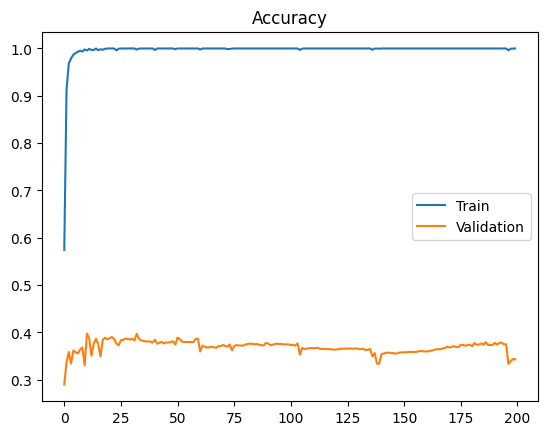

In [ ]:
# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

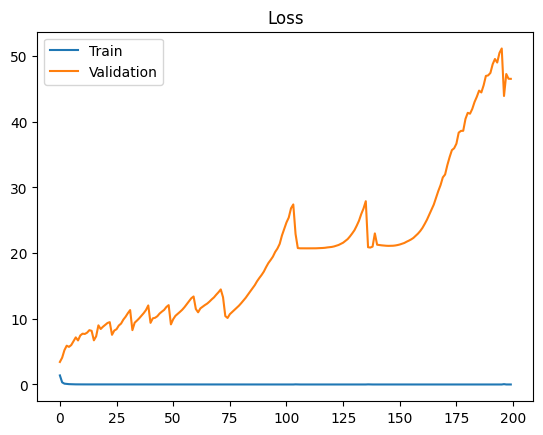

In [ ]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

355/355 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.2570 - loss: 34.8060
Driver-wise Test Accuracy: 0.33797600865364075


In [ ]:
sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)

time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step
Time per image (seconds): 0.043488308787345886
Time per image (milliseconds): 43.488308787345886


In [ ]:

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━

In [ ]:
def original_model(input_shape=(224,224,3),num_classes=10):
  inputs = layers.Input(shape=input_shape)

  # Normalization
  x = layers.Rescaling(1./255)(inputs)

  # Block 1
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.Conv2D(16, (7, 7), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 2
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.Conv2D(32, (5, 5), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Bloack 3
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # Block 4
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
  x = layers.AveragePooling2D((2, 2))(x)

  # conv 9 & 10
  x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
  x = layers.Conv2D(num_classes, (3, 3), padding="same")(x)

  # Global pooling layer
  x = layers.GlobalAveragePooling2D()(x)

  # Softmax
  outputs = layers.Softmax()(x)

  model = models.Model(inputs, outputs, name="Original_CNN")
  return model

In [ ]:
model1 = original_model()
model1.summary()

Model: "Original_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 112, 112, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 28, 28, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 14, 14, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 10)     │        23,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 10)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,474 (2.47 MB)

 Trainable params: 648,474 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[early_stop]
)

Epoch 1/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.1083 - loss: 2.3016 - val_accuracy: 0.1096 - val_loss: 2.3014
Epoch 2/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.1092 - loss: 2.3016 - val_accuracy: 0.1096 - val_loss: 2.3012
Epoch 3/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - accuracy: 0.1077 - loss: 2.3016 - val_accuracy: 0.1096 - val_loss: 2.3015
Epoch 4/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step - accuracy: 0.1092 - loss: 2.3016 - val_accuracy: 0.1096 - val_loss: 2.3013
Epoch 5/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 79s 60ms/step - accuracy: 0.1092 - loss: 2.3016 - val_accuracy: 0.1096 - val_loss: 2.3012
Epoch 6/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.1092 - loss: 2.3017 - val_accuracy: 0.1096 - val_loss: 2.3012
Epoch 7/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.1090 - loss: 2.3016 - val_accuracy: 0.1096 - val_loss: 2.3013
Epoch 8/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.1092 - loss: 2

In [ ]:
model1.save("/content/data/models/original_cnn.keras")

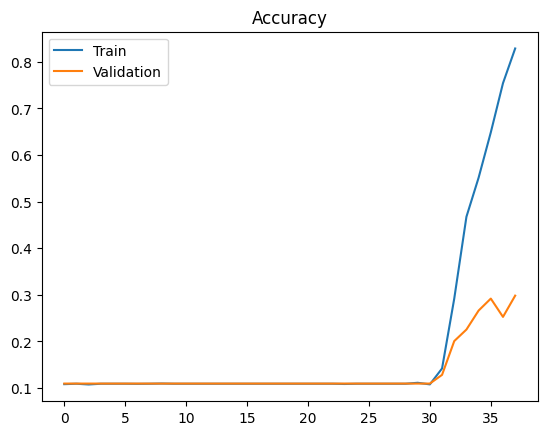

In [ ]:

# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

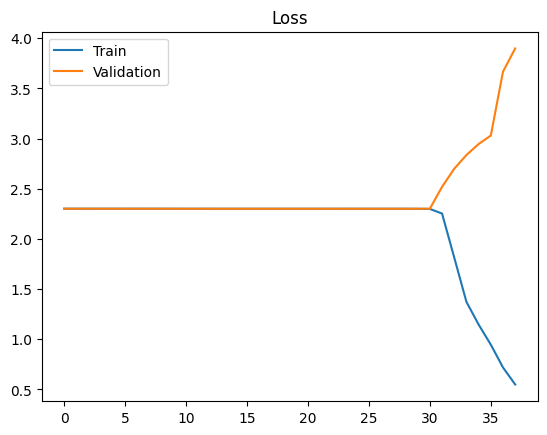

In [ ]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model1.evaluate(test_ds)
print("Test Accuracy:", test_acc)

355/355 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.1160 - loss: 2.2988
Test Accuracy: 0.116008460521698


In [ ]:
sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

NameError: name 'test_ds' is not defined

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

In [43]:
def improved_model(input_shape=(224,224,3), num_classes=10):
    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)

    # Normalization
    x = layers.Rescaling(1./255)(x)

    # Block 1
    x = layers.Conv2D(16, (7, 7), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(16, (7, 7), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.AveragePooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv2D(32, (5, 5), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(32, (5, 5), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.AveragePooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.AveragePooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Block 4
    x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.AveragePooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    # Final Conv
    x = layers.Conv2D(256, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(num_classes, (3, 3), padding="same")(x)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dropout before classification
    x = layers.Dropout(0.5)(x)

    outputs = layers.Softmax()(x)

    model = models.Model(inputs, outputs, name="Improved_CNN")
    return model

In [44]:
model1 = improved_model()
model1.summary()

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'input_layer_7' of layer 'functional_4' is incompatible with the layer: expected shape=(None, 256, 256, 3), found shape=(None, 224, 224, 3)[0m

Arguments received by Sequential.call():
  • args=('<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_682>',)
  • kwargs={'mask': 'None'}

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[early_stop]
)

Epoch 1/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.2115 - loss: 2.0236 - val_accuracy: 0.1422 - val_loss: 2.4796
Epoch 2/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 59s 69ms/step - accuracy: 0.3125 - loss: 1.7176 - val_accuracy: 0.2349 - val_loss: 3.0801
Epoch 3/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 58s 67ms/step - accuracy: 0.4749 - loss: 1.3969 - val_accuracy: 0.2388 - val_loss: 4.0437
Epoch 4/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.5856 - loss: 1.1225 - val_accuracy: 0.2579 - val_loss: 3.8805
Epoch 5/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - accuracy: 0.6670 - loss: 0.9345 - val_accuracy: 0.2494 - val_loss: 4.2900
Epoch 6/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.7106 - loss: 0.8312 - val_accuracy: 0.2394 - val_loss: 5.6902
Epoch 7/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - accuracy: 0.7628 - loss: 0.6847 - val_accuracy: 0.2524 - val_loss: 5.8850
Epoch 8/200
840/840 ━━━━━━━━━━━━━━━━━━━━ 57s 66ms/step - accuracy: 0.8022 - loss: 0

In [ ]:
model1.save("/content/data/models/improved_cnn_driversplit.keras")

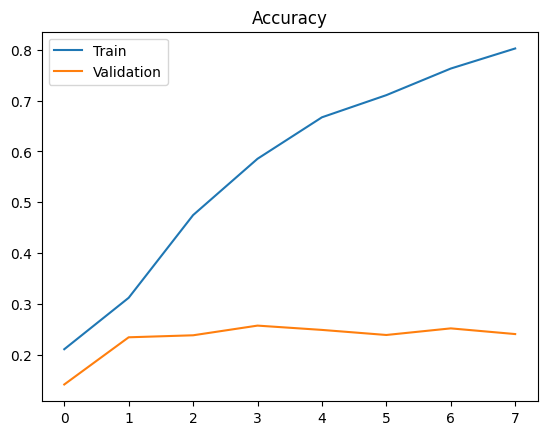

In [ ]:
# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

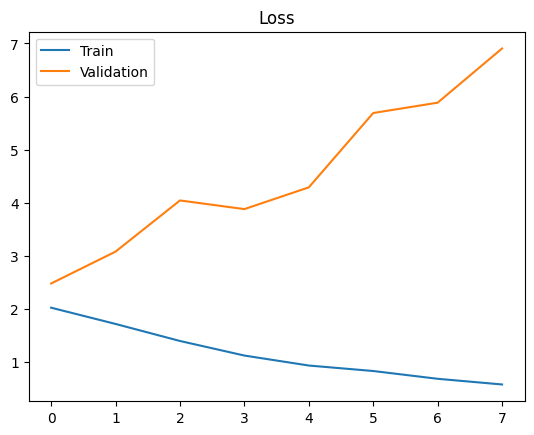

In [ ]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [ ]:
test_loss, test_acc = model1.evaluate(test_ds)
print("Test Accuracy:", test_acc)

355/355 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.1456 - loss: 2.2891
Test Accuracy: 0.14562764763832092


In [ ]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model1.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
Time per image (seconds): 0.04968695342540741


**Using MobileNet**

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [45]:
def mobilenet_driver_model(input_shape=(256,256,3), num_classes=10):

    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Preprocessing
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    # Base Model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model, base_model

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [47]:
model, base_model = mobilenet_driver_model()
model.summary()

/tmp/ipykernel_3124/3323726211.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 168,074 (656.54 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [ ]:


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

/tmp/ipykernel_2289/1554188786.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Epoch 1/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 66s 52ms/step - accuracy: 0.1530 - loss: 3.1272 - val_accuracy: 0.3137 - val_loss: 2.1012 - learning_rate: 1.0000e-04
Epoch 2/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 63s 54ms/step - accuracy: 0.2450 - loss: 2.5307 - val_accuracy: 0.3738 - val_loss: 1.9433 - learning_rate: 1.0000e-04
Epoch 3/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 56s 49ms/step - accuracy: 0.3138 - loss: 2.2332 - val_accuracy: 0.3871 - val_loss: 1.8986 - learning_rate: 1.0000e-04
Epoch 4/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 59s 50ms/step - accuracy: 0.3554 - loss: 2.0600 - val_accuracy: 0.4022 - val_loss: 1.8480 - learning_rate: 1.0000e-04
Epoch 5/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 58s 50ms/step - accuracy: 0.3889 - loss: 1.9463 - val_accuracy: 0.4034 - val_loss: 1.8266 - learning_rate: 1.0000e-04
Epoch 6/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.4167 - loss: 1.8450 - val_accuracy: 0.3880 - val_loss: 1.8772 - learning_rate: 1.0000e-04
Epoch 7/20
1120/1120 ━━━━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.3514 - loss: 1.9702
Driver-wise Test Accuracy: 0.35137516260147095


**MobileNet with last 40 trainable layer**

In [48]:
base_model.trainable = True

# Freeze most layers, train last 40
for layer in base_model.layers[:-40]:
    layer.trainable = False

In [49]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 1,849,610 (7.06 MB)

 Non-trainable params: 579,264 (2.21 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 93s 69ms/step - accuracy: 0.3324 - loss: 2.0895 - val_accuracy: 0.4928 - val_loss: 1.7162 - learning_rate: 1.0000e-05
Epoch 2/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - accuracy: 0.4452 - loss: 1.7954 - val_accuracy: 0.5311 - val_loss: 1.6502 - learning_rate: 1.0000e-05
Epoch 3/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 77s 67ms/step - accuracy: 0.5320 - loss: 1.5904 - val_accuracy: 0.5293 - val_loss: 1.6911 - learning_rate: 1.0000e-05
Epoch 4/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 75s 66ms/step - accuracy: 0.5993 - loss: 1.4444 - val_accuracy: 0.5791 - val_loss: 1.5816 - learning_rate: 1.0000e-05
Epoch 5/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.6551 - loss: 1.3288 - val_accuracy: 0.6018 - val_loss: 1.5392 - learning_rate: 1.0000e-05
Epoch 6/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 80s 65ms/step - accuracy: 0.7024 - loss: 1.2356 - val_accuracy: 0.6422 - val_loss: 1.4546 - learning_rate: 1.0000e-05
Epoch 7/20
1120/1120 ━━━━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

355/355 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.6232 - loss: 1.4149
Driver-wise Test Accuracy: 0.6232369542121887


**MobileNet with last 80 trainable layers**

In [50]:
def mobilenet_driver_model(input_shape=(256,256,3), num_classes=10):

    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Preprocessing
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    # Base Model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model, base_model

In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [52]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [53]:
model, base_model = mobilenet_driver_model()
model.summary()

/tmp/ipykernel_3124/3323726211.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_5 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 168,074 (656.54 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [30]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

/tmp/ipykernel_3124/3323726211.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Epoch 1/20


KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

473/473 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.3678 - loss: 1.8788
Driver-wise Test Accuracy: 0.3677715063095093


In [54]:
base_model.trainable = True

# Freeze most layers, train last 80
for layer in base_model.layers[:-80]:
    layer.trainable = False

In [55]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_5 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 2,235,786 (8.53 MB)

 Non-trainable params: 193,088 (754.25 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 119s 88ms/step - accuracy: 0.3856 - loss: 1.9119 - val_accuracy: 0.5030 - val_loss: 1.6608 - learning_rate: 1.0000e-05
Epoch 2/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 138s 85ms/step - accuracy: 0.5362 - loss: 1.5653 - val_accuracy: 0.5682 - val_loss: 1.5193 - learning_rate: 1.0000e-05
Epoch 3/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 99s 86ms/step - accuracy: 0.6414 - loss: 1.3511 - val_accuracy: 0.6220 - val_loss: 1.4271 - learning_rate: 1.0000e-05
Epoch 4/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 97s 85ms/step - accuracy: 0.7093 - loss: 1.2121 - val_accuracy: 0.6615 - val_loss: 1.3311 - learning_rate: 1.0000e-05
Epoch 5/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 142s 85ms/step - accuracy: 0.7624 - loss: 1.1148 - val_accuracy: 0.7017 - val_loss: 1.2579 - learning_rate: 1.0000e-05
Epoch 6/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 97s 85ms/step - accuracy: 0.8034 - loss: 1.0300 - val_accuracy: 0.7201 - val_loss: 1.2179 - learning_rate: 1.0000e-05
Epoch 7/20
1120/1120 ━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

473/473 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7489 - loss: 1.1368
Driver-wise Test Accuracy: 0.7489421963691711


**MobileNet with last 120 trainable layers**

In [56]:
def mobilenet_driver_model(input_shape=(256,256,3), num_classes=10):

    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Preprocessing
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    # Base Model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model, base_model

In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [58]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [59]:
model, base_model = mobilenet_driver_model()
model.summary()

/tmp/ipykernel_3124/3323726211.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_6 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_6 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 168,074 (656.54 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [20]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

/tmp/ipykernel_3124/3323726211.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.1568 - loss: 3.0920 - val_accuracy: 0.2666 - val_loss: 2.1581 - learning_rate: 1.0000e-04
Epoch 2/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - accuracy: 0.2414 - loss: 2.5158 - val_accuracy: 0.3222 - val_loss: 1.9959 - learning_rate: 1.0000e-04
Epoch 3/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.3077 - loss: 2.2423 - val_accuracy: 0.3551 - val_loss: 1.9189 - learning_rate: 1.0000e-04
Epoch 4/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 56s 48ms/step - accuracy: 0.3553 - loss: 2.0572 - val_accuracy: 0.3548 - val_loss: 1.9118 - learning_rate: 1.0000e-04
Epoch 5/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 58s 50ms/step - accuracy: 0.3898 - loss: 1.9408 - val_accuracy: 0.3632 - val_loss: 1.8683 - learning_rate: 1.0000e-04
Epoch 6/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 57s 49ms/step - accuracy: 0.4109 - loss: 1.8648 - val_accuracy: 0.3792 - val_loss: 1.8460 - learning_rate: 1.

In [21]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.3477 - loss: 1.9461
Driver-wise Test Accuracy: 0.34767279028892517


In [60]:
base_model.trainable = True

# Freeze most layers, train last 80
for layer in base_model.layers[:-120]:
    layer.trainable = False

In [61]:
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_6 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_6 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 2,370,826 (9.04 MB)

 Non-trainable params: 58,048 (226.75 KB)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.3573 - loss: 2.0023 - val_accuracy: 0.4934 - val_loss: 1.7118 - learning_rate: 1.0000e-05
Epoch 2/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 142s 105ms/step - accuracy: 0.5115 - loss: 1.6358 - val_accuracy: 0.5836 - val_loss: 1.4995 - learning_rate: 1.0000e-05
Epoch 3/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 118s 104ms/step - accuracy: 0.6132 - loss: 1.4090 - val_accuracy: 0.6301 - val_loss: 1.3929 - learning_rate: 1.0000e-05
Epoch 4/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 118s 104ms/step - accuracy: 0.6912 - loss: 1.2465 - val_accuracy: 0.6636 - val_loss: 1.3231 - learning_rate: 1.0000e-05
Epoch 5/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 142s 104ms/step - accuracy: 0.7472 - loss: 1.1353 - val_accuracy: 0.7126 - val_loss: 1.2357 - learning_rate: 1.0000e-05
Epoch 6/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 142s 104ms/step - accuracy: 0.7905 - loss: 1.0599 - val_accuracy: 0.7376 - val_loss: 1.1763 - learning_rate: 1.0000e-05
Epoch 7/20
1120/1120 ━━━━━━━

In [24]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.7532 - loss: 1.1319
Driver-wise Test Accuracy: 0.7531734704971313


**MobileNet with 80 trainable layers with increasing epochs**

In [62]:
def mobilenet_driver_model(input_shape=(256,256,3), num_classes=10):

    inputs = layers.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Preprocessing
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    # Base Model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    x = base_model(x, training=False)

    # Classification Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    return model, base_model

In [63]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [64]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [65]:
model, base_model = mobilenet_driver_model()
model.summary()

/tmp/ipykernel_3124/3323726211.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_7 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_7 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 168,074 (656.54 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [34]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop, reduce_lr]
)

/tmp/ipykernel_3124/3323726211.py:12: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Epoch 1/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 70s 52ms/step - accuracy: 0.1608 - loss: 3.1092 - val_accuracy: 0.2264 - val_loss: 2.3335 - learning_rate: 1.0000e-04
Epoch 2/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.2515 - loss: 2.5516 - val_accuracy: 0.3007 - val_loss: 2.1430 - learning_rate: 1.0000e-04
Epoch 3/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 57s 50ms/step - accuracy: 0.3086 - loss: 2.2661 - val_accuracy: 0.3418 - val_loss: 2.0512 - learning_rate: 1.0000e-04
Epoch 4/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 80s 48ms/step - accuracy: 0.3590 - loss: 2.0710 - val_accuracy: 0.3560 - val_loss: 2.0242 - learning_rate: 1.0000e-04
Epoch 5/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 55s 48ms/step - accuracy: 0.3807 - loss: 1.9742 - val_accuracy: 0.3717 - val_loss: 2.0347 - learning_rate: 1.0000e-04
Epoch 6/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.4154 - loss: 1.8637 - val_accuracy: 0.3671 - val_loss: 2.0520 - learning_rate: 1.0000e-04
Epoch 7/35
1120/1120 ━━━━━━━━━━━━━━━━━━━

In [35]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

473/473 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.2916 - loss: 2.0241
Driver-wise Test Accuracy: 0.29160788655281067


In [66]:
base_model.trainable = True

# Freeze most layers, train last 80
for layer in base_model.layers[:-80]:
    layer.trainable = False

In [67]:
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_7 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_7 (Subtract)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,874 (9.27 MB)

 Trainable params: 2,235,786 (8.53 MB)

 Non-trainable params: 193,088 (754.25 KB)

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 113s 83ms/step - accuracy: 0.3822 - loss: 1.9370 - val_accuracy: 0.4976 - val_loss: 1.7255 - learning_rate: 1.0000e-05
Epoch 2/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 96s 84ms/step - accuracy: 0.5407 - loss: 1.5580 - val_accuracy: 0.5637 - val_loss: 1.5675 - learning_rate: 1.0000e-05
Epoch 3/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 93s 82ms/step - accuracy: 0.6376 - loss: 1.3562 - val_accuracy: 0.6171 - val_loss: 1.4254 - learning_rate: 1.0000e-05
Epoch 4/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 95s 83ms/step - accuracy: 0.7115 - loss: 1.2107 - val_accuracy: 0.6603 - val_loss: 1.3450 - learning_rate: 1.0000e-05
Epoch 5/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 94s 82ms/step - accuracy: 0.7568 - loss: 1.1159 - val_accuracy: 0.6893 - val_loss: 1.2764 - learning_rate: 1.0000e-05
Epoch 6/35
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 95s 83ms/step - accuracy: 0.7983 - loss: 1.0434 - val_accuracy: 0.7313 - val_loss: 1.2166 - learning_rate: 1.0000e-05
Epoch 7/35
1120/1120 ━━━━━━━━━━━━━━━━━━

In [38]:
test_loss, test_acc = model.evaluate(test_ds)
print("Driver-wise Test Accuracy:", test_acc)

473/473 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.7664 - loss: 1.0991
Driver-wise Test Accuracy: 0.7663963437080383


In [40]:
model.save("/content/data/models/mobileNet80_imp1.keras")

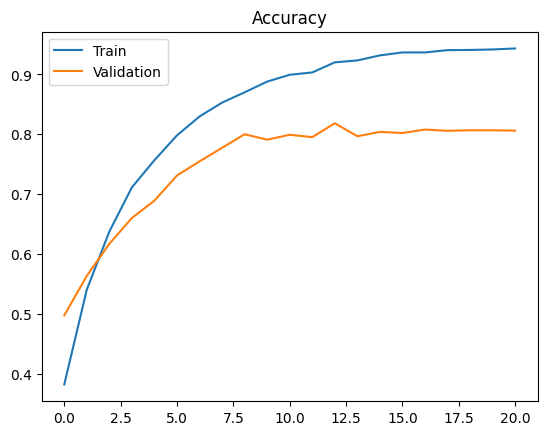

In [41]:
# Accuracy curve
plt.plot(history_fine.history['accuracy'])
plt.plot(history_fine.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

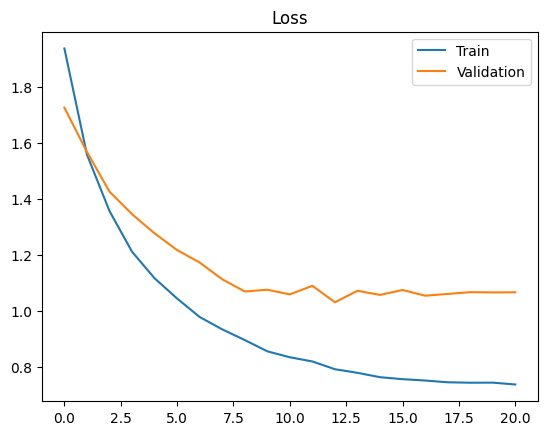

In [42]:
# Loss curve
plt.plot(history_fine.history['loss'])
plt.plot(history_fine.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [68]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Time per image (seconds): 0.11419989665349324
Time per image (milliseconds): 114.19989665349324
